In [6]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.utils import ModelInputOutputWrapper
from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "mnist"

default_architecutre_mapping = {
    "mnist": "resnet_small",
    "bigger_mnist": "resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist": "bigger_extended_resnet_small",
    "coil100": "coil_resnet_small",
    "tu_berlin": "bi_lstm",
    "modelnet10": "pointnetplus",
}

architecture = default_architecutre_mapping[dataset]
budget = None
from utils.transforms.apply import grid_resample_border, grid_resample_reflection

from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info, get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info, path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

In [7]:
from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method,
    init_method="sobol"
    ).to(device)

In [8]:
import torch
import torch.nn.functional as F
import kornia

def augment_true(images, max_shift=1.0, max_angle=3.0, max_scale=0.04):
    B, C, H, W = images.shape
    device = images.device

    # random translations in pixels
    translations = torch.empty(B, 2, device=device).uniform_(-max_shift, max_shift)

    # random angles in radians
    angles = torch.empty(B, device=device).uniform_(-max_angle, max_angle)

    # random scales
    scales = 1.0 + torch.empty(B, device=device).uniform_(-max_scale, max_scale)
    scales = scales.unsqueeze(1).repeat(1, 2)

    # center of image
    center = torch.tensor([[W / 2, H / 2]], device=device).expand(B, -1)

    # get 3x3 affine matrices in pixel coordinates
    M_3x3 = kornia.geometry.transform.get_affine_matrix2d(translations, center, scales, angles)

    # normalize to PyTorch [-1,1] coordinates
    norm_mat = torch.tensor([
        [2.0/(W-1), 0, -1],
        [0, 2.0/(H-1), -1],
        [0, 0, 1]
    ], device=device).unsqueeze(0).repeat(B,1,1)

    norm_mat_inv = torch.tensor([
        [(W-1)/2.0, 0, (W-1)/2.0],
        [0, (H-1)/2.0, (H-1)/2.0],
        [0, 0, 1]
    ], device=device).unsqueeze(0).repeat(B,1,1)

    # properly transform 3x3 matrices
    M_norm_3x3 = torch.bmm(norm_mat, torch.bmm(M_3x3, norm_mat_inv))

    # slice to 2x3 for affine_grid
    M_norm_2x3 = M_norm_3x3[:, :2, :]

    # create grid and warp
    grid = F.affine_grid(M_norm_2x3, images.size(), align_corners=False)
    res = F.grid_sample(images, grid, mode='bilinear', padding_mode='zeros', align_corners=False)

    return res

import torch
import torch.nn.functional as F
import kornia as K
from typing import Tuple, Callable, List, Optional

Tensor = torch.Tensor

def _rand_params(shape, device, low, high):
    return torch.empty(shape, device=device).uniform_(low, high)

@torch.no_grad()
def random_gaussian_blur(x: Tensor,
                         p: float = 0.5,
                         ksize_choices: Tuple[int, ...] = (3, 5),
                         sigma_range: Tuple[float, float] = (0.1, 1.5)) -> Tensor:
    """
    Vectorized per-sample Gaussian blur.
    """
    if p <= 0:
        return x
    B, C, H, W = x.shape
    device = x.device
    apply_mask = torch.rand(B, device=device) < p
    if not apply_mask.any():
        return x
    # Choose kernel size per sample
    k_choices = torch.tensor(ksize_choices, device=device)
    k_idx = torch.randint(0, len(k_choices), (B,), device=device)
    k_sizes = k_choices[k_idx]

    # Sample sigmas per sample (Kornia expects (B,2))
    sigmas = _rand_params((B, 2), device, *sigma_range)
    # Build blurred batch
    out = x.clone()
    # Group by kernel size to avoid looping over samples
    for k in k_choices.unique():
        mask_k = (k_sizes == k) & apply_mask
        if not mask_k.any():
            continue
        x_sub = x[mask_k]
        sigma_sub = sigmas[mask_k]
        blur = K.filters.GaussianBlur2d((int(k.item()), int(k.item())), sigma_sub)(x_sub)
        out[mask_k] = blur
    return out

@torch.no_grad()
def random_unsharp_mask(x: Tensor,
                        p: float = 0.5,
                        ksize: int = 5,
                        sigma_range: Tuple[float, float] = (0.5, 1.5),
                        amount_range: Tuple[float, float] = (0.5, 1.5),
                        clamp: bool = True) -> Tensor:
    """
    Sharpen / deblur via unsharp masking: y = x + a * (x - blur(x)).
    """
    if p <= 0:
        return x
    B = x.shape[0]
    device = x.device
    apply_mask = torch.rand(B, device=device) < p
    if not apply_mask.any():
        return x
    sigmas = _rand_params((B, 2), device, *sigma_range)
    amounts = _rand_params((B, 1, 1, 1), device, *amount_range)
    blur_all = K.filters.GaussianBlur2d((ksize, ksize), sigmas)(x)
    sharpened = x + amounts * (x - blur_all)
    if clamp:
        sharpened = sharpened.clamp(0.0, 1.0)
    return torch.where(apply_mask.view(B, 1, 1, 1), sharpened, x)

@torch.no_grad()
def random_gaussian_noise(x: Tensor,
                          p: float = 0.5,
                          sigma_range: Tuple[float, float] = (0.001, 0.05),
                          clamp: bool = True) -> Tensor:
    if p <= 0:
        return x
    B = x.shape[0]
    device = x.device
    mask = torch.rand(B, device=device) < p
    if not mask.any():
        return x
    sigmas = _rand_params((B, 1, 1, 1), device, *sigma_range)
    noise = torch.randn_like(x) * sigmas
    out = x + noise
    if clamp:
        out = out.clamp(0.0, 1.0)
    return torch.where(mask.view(B,1,1,1), out, x)

@torch.no_grad()
def random_contrast(x: Tensor,
                    p: float = 0.5,
                    factor_range: Tuple[float, float] = (0.75, 1.25),
                    eps: float = 1e-8) -> Tensor:
    if p <= 0:
        return x
    B = x.shape[0]
    device = x.device
    mask = torch.rand(B, device=device) < p
    if not mask.any():
        return x
    factors = _rand_params((B,1,1,1), device, *factor_range)
    mean = x.mean(dim=(2,3), keepdim=True)
    out = (x - mean) * factors + mean
    out = torch.where(mask.view(B,1,1,1), out, x)
    return out.clamp(0.0, 1.0)

@torch.no_grad()
def random_gamma(x: Tensor,
                 p: float = 0.5,
                 gamma_range: Tuple[float, float] = (0.7, 1.5),
                 eps: float = 1e-8) -> Tensor:
    if p <= 0:
        return x
    B = x.shape[0]
    device = x.device
    mask = torch.rand(B, device=device) < p
    if not mask.any():
        return x
    gammas = _rand_params((B,1,1,1), device, *gamma_range)
    out = (x.clamp(min=eps)) ** gammas
    return torch.where(mask.view(B,1,1,1), out, x)

@torch.no_grad()
def random_cutout(x: Tensor,
                  p: float = 0.5,
                  scale_range: Tuple[float, float] = (0.1, 0.25),
                  fill: float = 0.0) -> Tensor:
    """
    Rectangular mask with random size per sample.
    """
    if p <= 0:
        return x
    B, C, H, W = x.shape
    device = x.device
    mask_apply = torch.rand(B, device=device) < p
    if not mask_apply.any():
        return x
    out = x.clone()
    for_mask = torch.nonzero(mask_apply).flatten()
    # Vectorizable approach: build per-pixel mask
    yy = torch.arange(H, device=device).view(1, H, 1)
    xx = torch.arange(W, device=device).view(1, 1, W)
    for b in for_mask:
        scale = _rand_params((1,), device, *scale_range).item()
        cut_h = max(1, int(H * scale))
        cut_w = max(1, int(W * scale))
        cy = torch.randint(0, H, (1,), device=device).item()
        cx = torch.randint(0, W, (1,), device=device).item()
        y1 = max(0, cy - cut_h // 2); y2 = min(H, y1 + cut_h)
        x1 = max(0, cx - cut_w // 2); x2 = min(W, x1 + cut_w)
        out[b,:,y1:y2,x1:x2] = fill
    return out

@torch.no_grad()
def random_blur_or_sharpen(
    x: torch.Tensor,
    p: float = 0.4,
    prob_blur: float = 0.5,           # fraction of affected samples that get blur; rest sharpen
    blur_ks_choices=(3,5),
    blur_sigma_range=(0.2,1.2),
    usm_ksize=5,
    usm_sigma_range=(0.5,1.5),
    usm_amount_range=(0.5,1.3),
    clamp: bool = True
) -> torch.Tensor:
    """
    Per sample choose: no-op, Gaussian blur, or unsharp mask (sharpen).
    """
    if p <= 0:
        return x
    B, C, H, W = x.shape
    device = x.device

    apply_mask = torch.rand(B, device=device) < p
    if not apply_mask.any():
        return x

    # Decide which of the applying samples get blur vs sharpen
    apply_indices = torch.nonzero(apply_mask).flatten()
    n_apply = apply_indices.numel()
    n_blur = int(round(n_apply * prob_blur))
    # Shuffle
    perm = apply_indices[torch.randperm(n_apply, device=device)]
    blur_indices = perm[:n_blur]
    sharp_indices = perm[n_blur:]

    out = x.clone()

    # --- Blur branch ---
    if blur_indices.numel() > 0:
        k_choices = torch.tensor(blur_ks_choices, device=device)
        # kernel per sample
        k_idx = torch.randint(0, len(k_choices), (blur_indices.numel(),), device=device)
        k_sizes = k_choices[k_idx]
        sigmas = torch.empty(blur_indices.numel(), 2, device=device).uniform_(*blur_sigma_range)
        for ks in k_choices.unique():
            sel = (k_sizes == ks)
            if not sel.any():
                continue
            idx_sel = blur_indices[sel]
            x_sub = x[idx_sel]
            sigma_sub = sigmas[sel]
            blur_op = K.filters.GaussianBlur2d((int(ks.item()), int(ks.item())), sigma_sub)
            out[idx_sel] = blur_op(x_sub)

    # --- Sharpen (unsharp mask) branch ---
    if sharp_indices.numel() > 0:
        sigmas = torch.empty(sharp_indices.numel(), 2, device=device).uniform_(*usm_sigma_range)
        amounts = torch.empty(sharp_indices.numel(), 1, 1, 1, device=device).uniform_(*usm_amount_range)
        blur_op = K.filters.GaussianBlur2d((usm_ksize, usm_ksize), sigmas)
        base = x[sharp_indices]
        blurred = blur_op(base)
        sharpened = base + amounts * (base - blurred)
        if clamp:
            sharpened = sharpened.clamp(0,1)
        out[sharp_indices] = sharpened

    return out

class ComposeAugmentations:
    def __init__(self, ops: List[Callable[[Tensor], Tensor]]):
        self.ops = ops
    @torch.no_grad()
    def __call__(self, x: Tensor) -> Tensor:
        for op in self.ops:
            x = op(x)
        return x

def build_default_augmentations() -> ComposeAugmentations:
    return ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),
        lambda x: random_gaussian_noise(x, p=0.3),
        lambda x: random_contrast(x, p=0.3),
        lambda x: random_gamma(x, p=0.3),
    ])


In [9]:

train_transformed_loader = dataset_dict['train_loader_transformed']
batch_size = dataset_info.batch_size

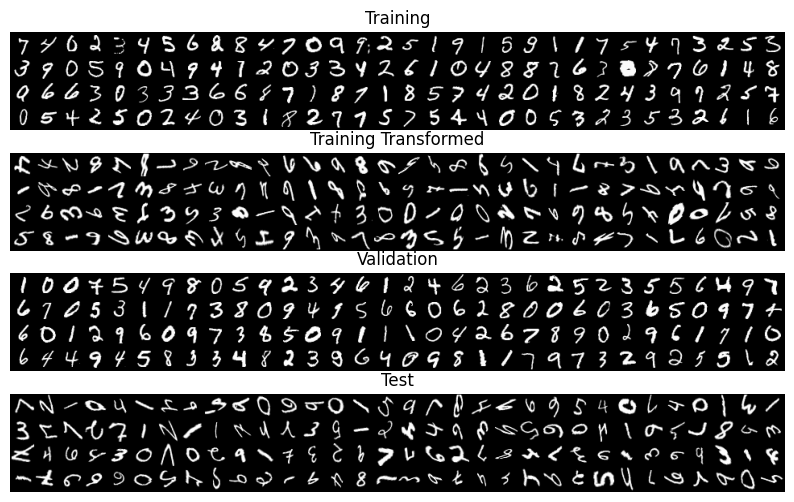

In [10]:
 #test images
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(10, 6))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(train_transformed_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[3].imshow(torchvision.utils.make_grid(next(iter(test_loader_transformed))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Training Transformed')
axs[2].set_title('Validation')
axs[3].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [11]:
from model.classifier import Classifier, MyProgressBar
import pytorch_lightning as pl
import os

model_path = f'../model/{dataset}_rot_only.pth'

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.ReLU(),
    nn.AdaptiveAvgPool2d((7, 7)),                            # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)


# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=10,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader,val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader_transformed)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


Loading model from ../model/mnist_rot_only.pth


C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:

from equiadapt.images.canonicalization.discrete_group import OptimizedGroupEquivariantImageCanonicalization,GroupEquivariantImageCanonicalization

In [13]:
from equiadapt.images.canonicalization_networks import (
    ConvNetwork,
    CustomEquivariantNetwork,
    ESCNNEquivariantNetwork,
    ESCNNSteerableNetwork,
    ESCNNWRNEquivariantNetwork,
    ResNet18Network,
    WideResNet50Network,
    WideResNet101Network,
)

In [14]:

from omegaconf import OmegaConf
canonicalization_network = ESCNNEquivariantNetwork(
    in_shape=dataset_info.input_shape,
    out_channels=32,num_layers=3,kernel_size=3,num_rotations=8,
)
#remove the dropout layers if any
#canonicalization_network.final_fc = nn.Sequential(*[layer for layer in canonicalization_network.final_fc if not isinstance(layer, nn.Dropout1d)])

dict_config = OmegaConf.create({
    "group_type": "rotation",
    "num_rotations":8,
    "artifact_err_wt":0,
    "learn_ref_vec" :False,
    "input_crop_ratio": 1.0,
    "resize_shape": 28,
    "beta": 1.0,
    "gradient_trick":None
})

canonicalizer = GroupEquivariantImageCanonicalization(canonicalization_network,
dict_config,(1, 28, 28)).cuda()

In [15]:
canonicalization_network

ESCNNEquivariantNetwork(
  (eqv_network): SequentialModule(
    (0): R2Conv([C8_on_R2[(None, 8)]: {irrep_0 (x1)}(1)], [C8_on_R2[(None, 8)]: {regular (x32)}(256)], kernel_size=3, stride=1)
    (1): InnerBatchNorm([C8_on_R2[(None, 8)]: {regular (x32)}(256)], eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True, type=[C8_on_R2[(None, 8)]: {regular (x32)}(256)])
    (3): PointwiseDropout()
    (4): R2Conv([C8_on_R2[(None, 8)]: {regular (x32)}(256)], [C8_on_R2[(None, 8)]: {regular (x32)}(256)], kernel_size=3, stride=1)
    (5): InnerBatchNorm([C8_on_R2[(None, 8)]: {regular (x32)}(256)], eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True, type=[C8_on_R2[(None, 8)]: {regular (x32)}(256)])
    (7): PointwiseDropout()
    (8): R2Conv([C8_on_R2[(None, 8)]: {regular (x32)}(256)], [C8_on_R2[(None, 8)]: {regular (x32)}(256)], kernel_size=3, stride=1)
  )
)

In [16]:
model.cuda().eval()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): AdaptiveAvgPool2d(output_size=(7, 7))
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [17]:
def test():
    with torch.no_grad():
        avg_acc = 0
        avg_loss = 0
        for batch in tqdm.tqdm(val_loader):
            x, y = batch
            x = x.cuda()
            x_canonicalized = canonicalizer(x)
            logits = model(x_canonicalized)
            output = logits.argmax(dim=-1)
            loss = nn.CrossEntropyLoss()(logits, y.cuda())
            acc = output.eq(y.cuda()).sum().item()
            avg_acc += acc
            avg_loss += loss.item()
        avg_acc /= len(val_loader.dataset)
        print(f'Accuracy on the test set after canonicalization: {avg_acc}.')
        print(f'Loss on the test set after canonicalization: {avg_loss/len(val_loader)}.')
import tqdm
opt = torch.optim.Adam(canonicalizer.parameters(), lr=1e-3)
for i in range(10):
    pbar = tqdm.tqdm(train_loader)
    for batch in pbar:
        opt.zero_grad()
        x, y = batch
        x = x.cuda()
        #augment with gaussian blur
        #blur_kernel_size = 3
        #x = random_blur_or_sharpen(x, p=0.5, blur_ks_choices=(3,), prob_blur=1.0)

        x_canonicalized = canonicalizer(x)

        loss =  torch.zeros(1, device='cuda')
        logits = model(x_canonicalized)
        task_loss = torch.nn.functional.cross_entropy(logits, y.cuda())
        loss =  loss + task_loss
        prior_loss = canonicalizer.get_prior_regularization_loss()
        loss += prior_loss*100.0
        #specific_loss = canonicalizer.get_optimization_specific_loss()
        #loss += specific_loss*1e-4
        loss.backward()
        opt.step()
        #log in obar
        pbar.set_description(f"Loss: {loss.item():.4f}, Prior Loss: {prior_loss.item():.4f}, Task Loss: {task_loss.item():.4f}")
    test()



Loss: 53.2926, Prior Loss: 0.5124, Task Loss: 2.0494: 100%|██████████| 422/422 [00:27<00:00, 15.46it/s] 
100%|██████████| 47/47 [00:01<00:00, 43.83it/s]


Accuracy on the test set after canonicalization: 0.8151666666666667.
Loss on the test set after canonicalization: 3.147161656237663.


Loss: 68.9367, Prior Loss: 0.6589, Task Loss: 3.0486: 100%|██████████| 422/422 [00:26<00:00, 15.79it/s]
100%|██████████| 47/47 [00:01<00:00, 44.07it/s]


Accuracy on the test set after canonicalization: 0.8453333333333334.
Loss on the test set after canonicalization: 2.6394623112171254.


Loss: 51.8291, Prior Loss: 0.4920, Task Loss: 2.6253: 100%|██████████| 422/422 [00:26<00:00, 15.84it/s]
100%|██████████| 47/47 [00:01<00:00, 43.62it/s]


...

Accuracy on the test set after canonicalization: 0.878.
Loss on the test set after canonicalization: 1.8480718643107312.


Loss: 48.2909, Prior Loss: 0.4587, Task Loss: 2.4166: 100%|██████████| 422/422 [00:26<00:00, 15.82it/s]
100%|██████████| 47/47 [00:01<00:00, 44.26it/s]


Accuracy on the test set after canonicalization: 0.8846666666666667.
Loss on the test set after canonicalization: 1.781864696360649.


Loss: 38.1459, Prior Loss: 0.3686, Task Loss: 1.2856: 100%|██████████| 422/422 [00:26<00:00, 15.88it/s]
100%|██████████| 47/47 [00:01<00:00, 40.57it/s]

Accuracy on the test set after canonicalization: 0.886.
Loss on the test set after canonicalization: 1.7708299248776538.


In [18]:
canonicalizer.eval()

GroupEquivariantImageCanonicalization(
  (canonicalization_network): ESCNNEquivariantNetwork(
    (eqv_network): SequentialModule(
      (0): R2Conv([C8_on_R2[(None, 8)]: {irrep_0 (x1)}(1)], [C8_on_R2[(None, 8)]: {regular (x32)}(256)], kernel_size=3, stride=1)
      (1): InnerBatchNorm([C8_on_R2[(None, 8)]: {regular (x32)}(256)], eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True, type=[C8_on_R2[(None, 8)]: {regular (x32)}(256)])
      (3): PointwiseDropout()
      (4): R2Conv([C8_on_R2[(None, 8)]: {regular (x32)}(256)], [C8_on_R2[(None, 8)]: {regular (x32)}(256)], kernel_size=3, stride=1)
      (5): InnerBatchNorm([C8_on_R2[(None, 8)]: {regular (x32)}(256)], eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True, type=[C8_on_R2[(None, 8)]: {regular (x32)}(256)])
      (7): PointwiseDropout()
      (8): R2Conv([C8_on_R2[(None, 8)]: {regular (x32)}(256)], [C8_on_R2[(None, 8)]: {regular (x32)}(256)], kernel_s

In [19]:
canonicalizer.eval().cuda()

GroupEquivariantImageCanonicalization(
  (canonicalization_network): ESCNNEquivariantNetwork(
    (eqv_network): SequentialModule(
      (0): R2Conv([C8_on_R2[(None, 8)]: {irrep_0 (x1)}(1)], [C8_on_R2[(None, 8)]: {regular (x32)}(256)], kernel_size=3, stride=1)
      (1): InnerBatchNorm([C8_on_R2[(None, 8)]: {regular (x32)}(256)], eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True, type=[C8_on_R2[(None, 8)]: {regular (x32)}(256)])
      (3): PointwiseDropout()
      (4): R2Conv([C8_on_R2[(None, 8)]: {regular (x32)}(256)], [C8_on_R2[(None, 8)]: {regular (x32)}(256)], kernel_size=3, stride=1)
      (5): InnerBatchNorm([C8_on_R2[(None, 8)]: {regular (x32)}(256)], eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True, type=[C8_on_R2[(None, 8)]: {regular (x32)}(256)])
      (7): PointwiseDropout()
      (8): R2Conv([C8_on_R2[(None, 8)]: {regular (x32)}(256)], [C8_on_R2[(None, 8)]: {regular (x32)}(256)], kernel_s

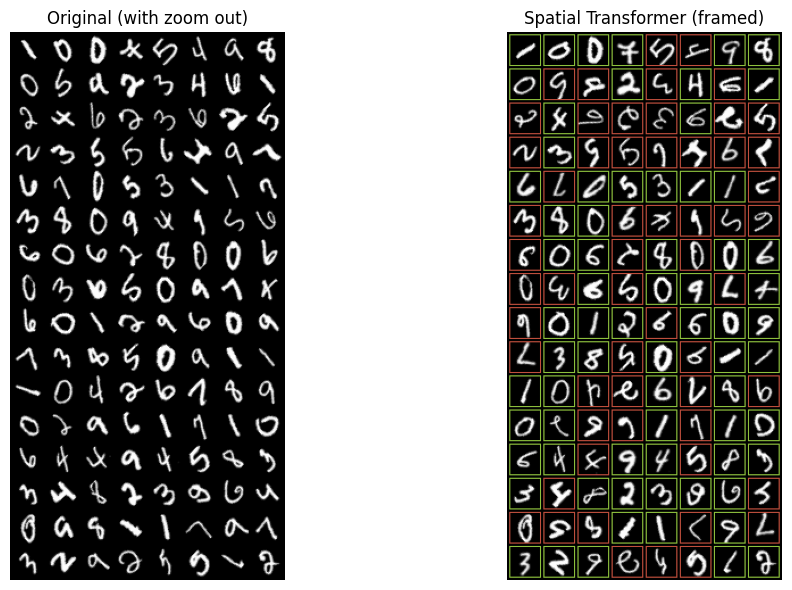

In [20]:
#validate on testset
import torchvision.transforms.functional
import kornia
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch

# zoom out (scale down and pad back)
def zoom_out(imgs, scale=0.7):
    B, C, H, W = imgs.shape
    new_H, new_W = int(H * scale), int(W * scale)

    # downscale
    zoomed = F.interpolate(imgs, size=(new_H, new_W), mode='bilinear', align_corners=False)

    # pad back to original size (centered)
    pad_h = (H - new_H) // 2
    pad_w = (W - new_W) // 2
    zoomed = F.pad(zoomed, (pad_w, W - new_W - pad_w, pad_h, H - new_H - pad_h))

    return zoomed

#validate on testset
#plot some samples
with torch.no_grad():
    # 1. Load a batch
    data, target = next(iter(val_loader))
    data, target = data.cuda(), target.cuda()

    # rotate by 45 degrees
    data = torchvision.transforms.functional.rotate(
        data, angle=45, interpolation=torchvision.transforms.InterpolationMode.BILINEAR
    )

    # apply gaussian blur
    #data = torchvision.transforms.GaussianBlur(3, 0.1)(data)

    # zoom out
    #data = zoom_out(data, scale=0.95)  # you can change 0.7 → 0.5 or 0.9 etc.

    # 2. Apply spatial transformer
    transformed = canonicalizer(data)

    # 3. Get predictions and correctness mask
    preds = model(transformed).argmax(dim=1)
    correct = preds.eq(target)

    # 4. Define frame colors
    green = torch.tensor((143, 194, 62))[:, None] / 255.
    red = torch.tensor((194, 80, 62))[:, None] / 255.

    # 5. Draw colored frames on transformed images
    imgs = transformed.repeat(1, 3, 1, 1)  # ensure 3 channels
    for img, is_correct in zip(imgs, correct):
        color = green if is_correct else red
        img[:, 0, :] = color
        img[:, -1, :] = color
        img[:, :, 0] = color
        img[:, :, -1] = color

    # 6. Plot original vs. framed outputs
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=8).permute(1, 2, 0), cmap='gray')
    axs[0].set_title('Original (with zoom out)')
    axs[0].axis('off')

    axs[1].imshow(torchvision.utils.make_grid(imgs.cpu(), nrow=8).permute(1, 2, 0))
    axs[1].set_title('Spatial Transformer (framed)')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()


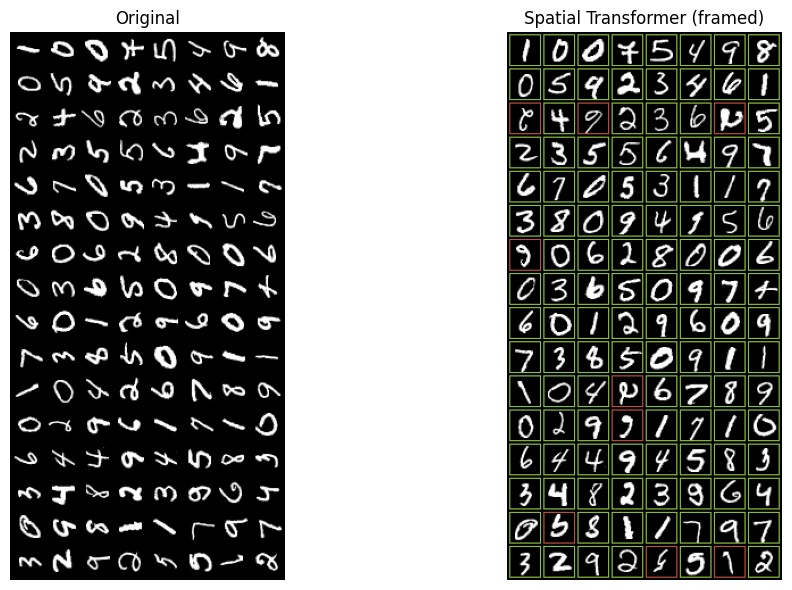

In [21]:
 #validate on testset
import torchvision.transforms.functional

#validate on testset
#plot some samples
with torch.no_grad():
    # 1. Load a batch
    data, target = next(iter(val_loader))
    data, target = data.cuda(), target.cuda()
    #roate by 1/17 of 2pi
    data = torchvision.transforms.functional.rotate(data, angle=90,interpolation=torchvision.transforms.InterpolationMode.BILINEAR)



    # 2. Apply spatial transformer
    transformed = canonicalizer(data)



    # 3. Get predictions and correctness mask
    preds = model(transformed).argmax(dim=1)
    correct = preds.eq(target)

    # 4. Define frame colors
    green = torch.tensor((143, 194, 62))[:, None] / 255.
    red = torch.tensor((194, 80, 62))[:, None] / 255.

    # 5. Draw colored frames on transformed images
    imgs = transformed.repeat(1, 3, 1, 1)  # ensure 3 channels
    for img, is_correct in zip(imgs, correct):
        color = green if is_correct else red
        img[:, 0, :] = color
        img[:, -1, :] = color
        img[:, :, 0] = color
        img[:, :, -1] = color

    # 6. Plot original vs. framed outputs
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=8).permute(1, 2, 0), cmap='gray')
    axs[0].set_title('Original')
    axs[0].axis('off')

    axs[1].imshow(torchvision.utils.make_grid(imgs.cpu(), nrow=8).permute(1, 2, 0))
    axs[1].set_title('Spatial Transformer (framed)')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()